In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from google.cloud import bigquery
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
params = yaml.safe_load(open("../params.yaml", encoding="utf-8"))
client = bigquery.Client()


def load_bq_table(table_id: str):
    query = f"SELECT * FROM `{table_id}`"
    return client.query(query).to_dataframe()


train_table = f"{params['bq']['bq_dataset']}.{params['bq']['train_table']}"
test_table = f"{params['bq']['bq_dataset']}.{params['bq']['test_table']}"

train_df = load_bq_table(train_table)
test_df = load_bq_table(test_table)

X_train, y_train = train_df.drop(columns=["Obesity"]), train_df["Obesity"]
X_test, y_test = test_df.drop(columns=["Obesity"]), test_df["Obesity"]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (1688, 17)
Test shape: (423, 17)


In [ ]:
T = params["train"]
models = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=15,
        random_state=T["random_state"],
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=T["n_estimators"],
        max_depth=5,
        random_state=T["random_state"],
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=T["random_state"],
    ),
}

In [4]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    pte = model.predict(X_test)

    cv_scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1
    )

    results[name] = {
        "test_accuracy": round(float(accuracy_score(y_test, pte)), 4),
        "test_f1_macro": round(float(f1_score(y_test, pte, average="macro")), 4),
        "test_precision_macro": round(
            float(precision_score(y_test, pte, average="macro")), 4
        ),
        "test_recall_macro": round(
            float(recall_score(y_test, pte, average="macro")), 4
        ),
        "cv_f1_macro_mean": round(float(cv_scores.mean()), 4),
        "cv_f1_macro_std": round(float(cv_scores.std()), 4),
    }


Training DecisionTree...

Training RandomForest...

Training GradientBoosting...


In [5]:
results_df = pd.DataFrame(results).T.sort_values(by="test_f1_macro", ascending=False)
results_df

,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,cv_f1_macro_mean,cv_f1_macro_std
GradientBoosting,0.8180,0.8174,0.8203,0.8164,0.7764,0.0545
DecisionTree,0.7707,0.7662,0.7671,0.7676,0.6854,0.0476
RandomForest,0.6832,0.6605,0.7052,0.6756,0.6348,0.0394


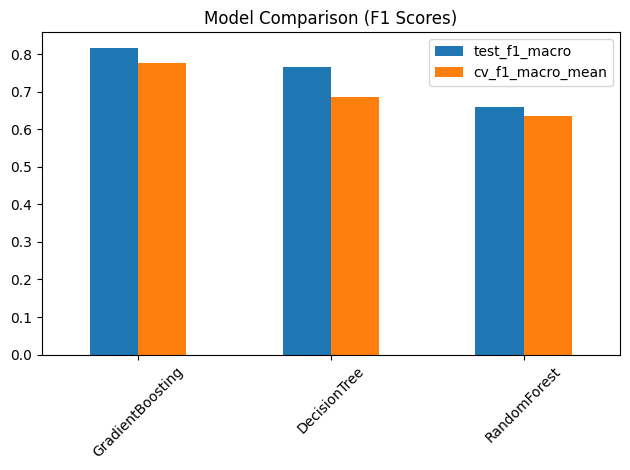

In [6]:
results_df[["test_f1_macro", "cv_f1_macro_mean"]].plot(kind="bar")
plt.title("Model Comparison (F1 Scores)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
param_grid = T["param_grid"]

base_clf = GradientBoostingClassifier(
    n_estimators=T["n_estimators"],
    random_state=T["random_state"],
)

grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'learning_rate': 0.2, 'max_depth': 7}
Best CV score: 0.7889085537798138


In [14]:
y_pred = grid_search.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("Test Accuracy:", round(accuracy * 100, 2))
print("Test F1:", round(f1 * 100, 2))
print("Test Precision:", round(precision * 100, 2))
print("Test Recall:", round(recall * 100, 2))

Test Accuracy: 83.92
Test F1: 83.98
Test Precision: 84.29
Test Recall: 84.02


In [17]:
cv_results = grid_search.cv_results_

# Extract all CV scores for the best model
best_index = grid_search.best_index_

std = grid_search.cv_results_["std_test_score"][best_index]

print("CV F1 mean", round(grid_search.best_score_ * 100, 2))
print("CV F1 std:", round(std * 100, 2))

CV F1 mean 78.89
CV F1 std: 4.9


In [12]:
importances = grid_search.best_estimator_.feature_importances_

fi_df = pd.DataFrame(
    {"feature": X_train.columns, "importance": importances}
).sort_values(by="importance", ascending=False)

print(fi_df)

                           feature  importance
1                              Age    0.177119
4                             FCVC    0.153193
11                             TUE    0.131105
5                              NCP    0.087441
10                             FAF    0.085346
8                             CH2O    0.077494
0                           Gender    0.073615
6                             CAEC    0.064475
2   family_history_with_overweight    0.046680
12                            CALC    0.040783
3                             FAVC    0.025501
13               MTRANS_automobile    0.014465
9                              SCC    0.008378
16                  MTRANS_walking    0.006924
7                            SMOKE    0.004896
14                     MTRANS_bike    0.001514
15                MTRANS_motorbike    0.001072


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    grid_search.best_estimator_,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame(
    {"feature": X_train.columns, "importance": perm.importances_mean}
).sort_values(by="importance", ascending=False)

print(perm_df)

,feature,importance
1,Age,0.233333
4,FCVC,0.183688
0,Gender,0.175414
11,TUE,0.126714
5,NCP,0.100946
10,FAF,0.068794
2,family_history_with_overweight,0.066194
8,CH2O,0.059811
12,CALC,0.048227
6,CAEC,0.032151
